# EDA with Time Series data

### Installing pandas data reader

In [3]:
import pandas_datareader as pdr
import pandas as pd
from datetime import datetime
import yfinance as yf

In [4]:
df_tesla = yf.download(
    "TSLA",
    start="2017-02-27",
    end="2022-02-24"
)

[*********************100%***********************]  1 of 1 completed


In [5]:
df_tesla.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000
2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500
2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500
2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000
2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000


In [6]:
df_tesla.shape

(1258, 5)

<Axes: xlabel='Date'>

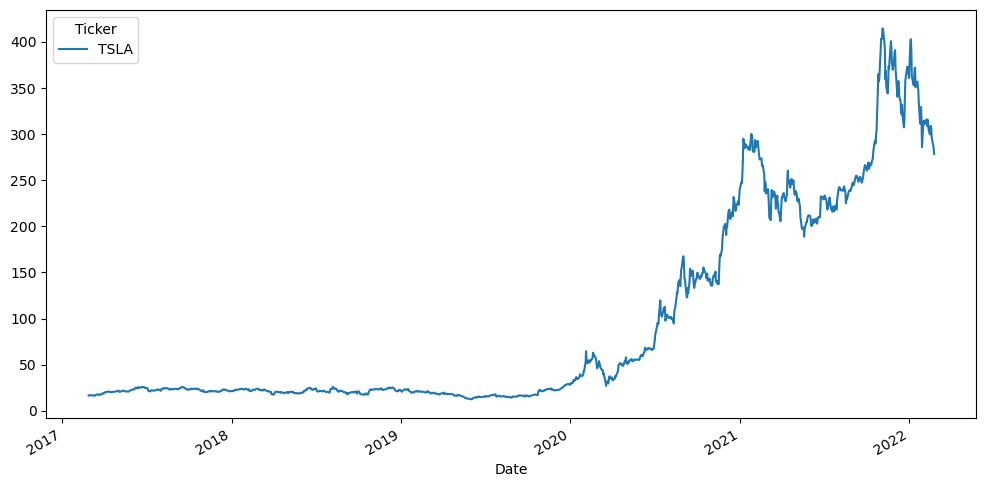

In [7]:
df_tesla['High'].plot(figsize=(12,6))

In [8]:
df_tesla.head(4)

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000
2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500
2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500
2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000


In [9]:
df_tesla.columns

MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])

In [10]:
index = df_tesla.loc['2020-01-01':'2021-09-01'].index
share_open = df_tesla.loc['2020-01-01':'2021-09-01']['Open','TSLA']

In [11]:
index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2021-08-19', '2021-08-20', '2021-08-23', '2021-08-24',
               '2021-08-25', '2021-08-26', '2021-08-27', '2021-08-30',
               '2021-08-31', '2021-09-01'],
              dtype='datetime64[ns]', name='Date', length=421, freq=None)

In [12]:
share_open

Date
2020-01-02     28.299999
2020-01-03     29.366667
2020-01-06     29.364668
2020-01-07     30.760000
2020-01-08     31.580000
                 ...    
2021-08-26    236.103333
2021-08-27    235.000000
2021-08-30    238.240005
2021-08-31    244.333328
2021-09-01    244.693329
Name: (Open, TSLA), Length: 421, dtype: float64

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

In [14]:
figure , axis = plt.subplots()
figure.autofmt_xdate() # This doesnot overlap the dates on the x axis
axis.plot(index,share_open)

In [15]:
df_tesla.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2017-02-27 to 2022-02-23
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   1258 non-null   float64
 1   (High, TSLA)    1258 non-null   float64
 2   (Low, TSLA)     1258 non-null   float64
 3   (Open, TSLA)    1258 non-null   float64
 4   (Volume, TSLA)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 91.3 KB


In [16]:
df = df_tesla.reset_index()

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        1258 non-null   datetime64[ns]
 1   (Close, TSLA)   1258 non-null   float64       
 2   (High, TSLA)    1258 non-null   float64       
 3   (Low, TSLA)     1258 non-null   float64       
 4   (Open, TSLA)    1258 non-null   float64       
 5   (Volume, TSLA)  1258 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 59.1 KB


### When the date column in not in date time format then use

In [19]:
pd.to_datetime(df['Date'])

0      2017-02-27
1      2017-02-28
2      2017-03-01
3      2017-03-02
4      2017-03-03
          ...    
1253   2022-02-16
1254   2022-02-17
1255   2022-02-18
1256   2022-02-22
1257   2022-02-23
Name: Date, Length: 1258, dtype: datetime64[ns]

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        1258 non-null   datetime64[ns]
 1   (Close, TSLA)   1258 non-null   float64       
 2   (High, TSLA)    1258 non-null   float64       
 3   (Low, TSLA)     1258 non-null   float64       
 4   (Open, TSLA)    1258 non-null   float64       
 5   (Volume, TSLA)  1258 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 59.1 KB


In [21]:
datetime.now()

datetime.datetime(2026, 1, 19, 17, 58, 10, 381330)

### Time resampling

In [23]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000
1,2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500
2,2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500
3,2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000
4,2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000


In [24]:
df = df.set_index('Date')

In [25]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000
2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500
2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500
2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000
2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000


In [26]:
df = df[['Open', 'Close', 'High', 'Low','Volume']]

In [27]:
df.resample(rule='YE').min() # YE refers to Year End 

Price,Open,Close,High,Low,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-12-31,16.279333,16.246000,16.433332,16.134001,43791000
2018-12-31,16.851999,16.704000,17.355333,16.306000,46210500
2019-12-31,12.073333,11.931333,12.445333,11.799333,36984000
2020-12-31,24.980000,24.081333,26.990667,23.367332,52073100
2021-12-31,184.183334,187.666672,188.736664,179.830002,29401800
2022-12-31,276.809998,254.679993,278.433319,253.520004,50729100


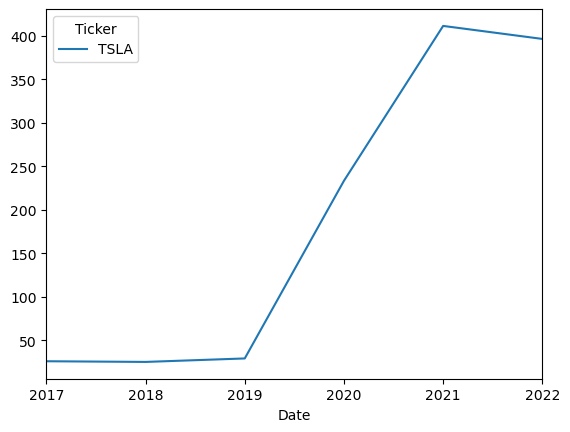

In [56]:
df.resample(rule='YE').max()['Open'].plot()
plt.show()